In [2]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def eval_metric(random_dir):

    norm_dists = []
    mismatches = []
    likelihoods = []
    inj_dirs = os.path.join(random_dir, 'injections')
    for inj_dir in os.listdir(inj_dirs):
        inj_dir = os.path.join(inj_dirs, inj_dir, 'outdir', 'output')

        # Load in metric and injected parameters
        try:
            filepath = os.path.join(inj_dir, 'analysis_metric.pkl')
            with open(filepath, 'rb') as f:
                metric = pickle.load(f)
            filepath = os.path.join(inj_dir, 'converted_injection_parameters.json')
            with open(filepath, 'r') as f:
                all_inj_params = json.load(f)
            if 'ecc10sqrd' not in all_inj_params['posterior_samples'].keys():
                if 'ecc10' in all_inj_params['posterior_samples'].keys():
                    all_inj_params['posterior_samples']['ecc10sqrd'] = [all_inj_params['posterior_samples']['ecc10'][0]**2]
        except:
            continue

        # Calculate distance, mismatch, and likelihood between peak and injected in dx coordinates
        inj_params = np.zeros(len(metric.dxs))
        for i, dx in enumerate(metric.dxs):
            inj_params[i] = all_inj_params['posterior_samples'][dx][0]
            inj_params[i] -= metric.x[dx][0]
        inj_params_dx = np.matmul(np.linalg.inv(metric.normalized_evecs().samples), inj_params)
        norm_dists.append(np.sqrt(np.sum(inj_params_dx**2)))
        mismatches.append(metric.mismatch[0]*norm_dists[-1]**2)
        if mismatches[-1] > 1:
            mismatches[-1] = 1
        likelihoods.append(np.exp(-metric.snr[0]**2/2 * (1-(1-mismatches[-1])**2)))

    return norm_dists, mismatches, likelihoods

Text(0, 0.5, 'Cumulative fraction')

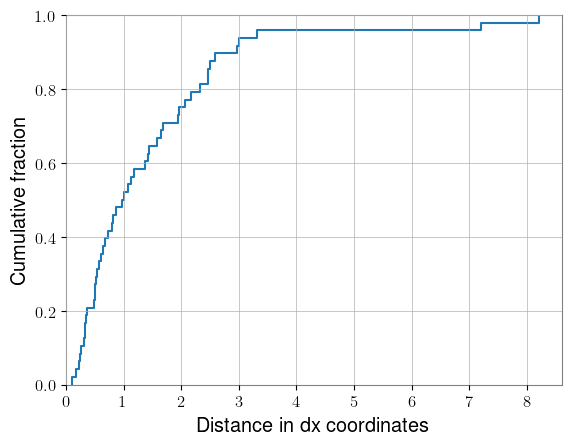

In [8]:
random_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/'
norm_dists, mismatches, likelihoods = eval_metric(random_dir)
sorted_dists = np.sort([*norm_dists, np.max(norm_dists)+10**-9])
plt.step(sorted_dists, np.arange(len(sorted_dists))/len(norm_dists))
plt.xlim(0,)
plt.ylim(0, 1)
plt.xlabel('Distance in dx coordinates')
plt.ylabel('Cumulative fraction')

Text(0, 0.5, 'Cumulative fraction')

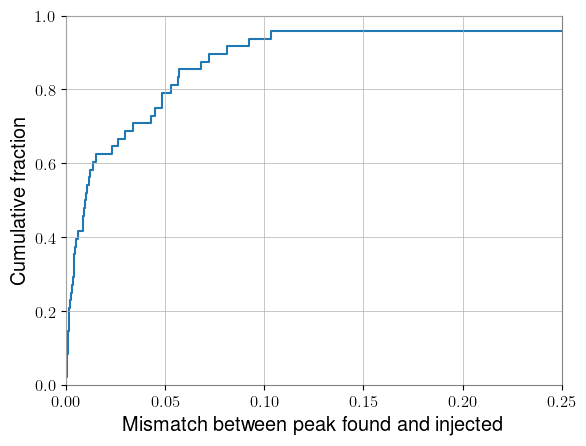

In [4]:
random_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/'
norm_dists, mismatches, likelihoods = eval_metric(random_dir)
sorted_ms = np.sort([*mismatches, np.max(mismatches)+10**-9])
plt.step(sorted_ms, np.arange(len(sorted_ms))/len(mismatches))
plt.xlim(0, 0.25)
plt.ylim(0, 1)
plt.xlabel('Mismatch between peak found and injected')
plt.ylabel('Cumulative fraction')

Text(0, 0.5, 'Cumulative fraction')

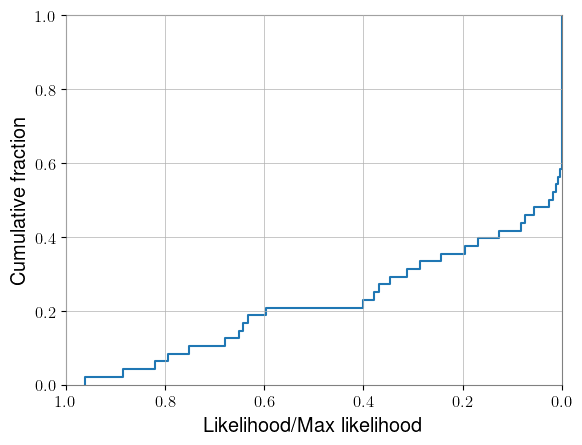

In [5]:
random_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/'
norm_dists, mismatches, likelihoods = eval_metric(random_dir)
sorted_Ls = np.sort([*likelihoods, np.min(mismatches)-10**-9])[::-1]
plt.step(sorted_Ls, np.arange(len(sorted_Ls))/len(likelihoods))
plt.xlim(1, 0)
plt.ylim(0, 1)
plt.xlabel('Likelihood/Max likelihood')
plt.ylabel('Cumulative fraction')